# Day 4: Embeddings, LLM Annotation, and Semantic Measurement

This notebook is designed to work without paid API access. The LLM annotation section uses a local Ollama model when available. The default is `llama3:latest`, because it is a chat/instruction model; `embeddinggemma:latest` is better suited for embeddings than for annotation.

By the end you should be able to:

1. Estimate and inspect a small n-gram language model.
2. Compute entropy, cross-entropy, and perplexity for toy text.
3. Treat prompting as codebook design.
4. Run local LLM annotation with Ollama and validate the labels.
5. Compare model labels to human labels.
6. Train local static word embeddings from context windows and average them into document vectors.
7. Use vector similarity for nearest neighbors and simple classifiers.
8. Build and stress-test a semantic axis.
9. Explain how contextual embeddings represent the same word differently across contexts.

In [1]:
from collections import Counter, defaultdict
import importlib.util
import json
import re
import time
import urllib.error
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore', message='IProgress not found.*')

pd.set_option('display.max_colwidth', 140)

In [2]:
from pathlib import Path


def find_data_dir():
    candidates = [Path('../data'), Path('materials/data'), Path('data')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find the course data directory.')


DATA_DIR = find_data_dir()
DATA_DIR

PosixPath('../data')

## spaCy setup

The notebooks use spaCy for tokenization and preprocessing. If `en_core_web_sm` is installed, the same setup also shows POS tags, lemmas, and dependency parses. If not, the notebooks still run with a blank English tokenizer.

In [3]:
import spacy

try:
    nlp = spacy.load('en_core_web_sm')
    print('Loaded spaCy model: en_core_web_sm')
except OSError:
    nlp = spacy.blank('en')
    nlp.add_pipe('sentencizer')
    print('Using spacy.blank("en"). Install en_core_web_sm for POS tags, lemmas, and dependency parses.')


def spacy_preprocess(text, remove_stop=True, keep_alpha=True, min_len=2):
    """Tokenize and lightly preprocess text with spaCy."""
    doc = nlp.make_doc(str(text))
    tokens = []
    for token in doc:
        if keep_alpha and not token.is_alpha:
            continue
        if remove_stop and token.is_stop:
            continue
        term = token.text.lower()
        if len(term) >= min_len:
            tokens.append(term)
    return tokens


def spacy_analyzer(text):
    return spacy_preprocess(text)


def spacy_analyzer_with_bigrams(text):
    tokens = spacy_preprocess(text)
    bigrams = [tokens[i] + '_' + tokens[i + 1] for i in range(len(tokens) - 1)]
    return tokens + bigrams


def spacy_token_table(text):
    """Show tokenization, preprocessing flags, and parses when a full model is available."""
    doc = nlp(str(text))
    rows = []
    for token in doc:
        rows.append({
            'text': token.text,
            'lemma': token.lemma_ or '(model needed)',
            'pos': token.pos_ or '(model needed)',
            'dep': token.dep_ or '(model needed)',
            'is_alpha': token.is_alpha,
            'is_stop': token.is_stop,
            'kept_by_preprocess': token.text.lower() in spacy_preprocess(token.text, remove_stop=True)
        })
    return pd.DataFrame(rows)

Loaded spaCy model: en_core_web_sm


## 1. Load a small short-text sentiment sample

We use the local TweetEval sentiment sample for short social-media-style text. To keep the first workflow binary and comparable to the previous notebooks, the core example uses only positive and negative labels.

In [4]:
tweets = pd.read_csv(DATA_DIR / 'tweet_eval_sentiment_sample.csv')
binary_tweets = tweets[tweets['label_name'].isin(['negative', 'positive'])].copy()
binary_tweets = binary_tweets.rename(columns={'label_name': 'polarity'})

pieces = []
for polarity, group in binary_tweets.groupby('polarity'):
    pieces.append(group.sample(250, random_state=42))

sample = (
    pd.concat(pieces, ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

sample[['text', 'polarity', 'split']].head(), sample['polarity'].value_counts()

(                                                                                                                       text  \
 0                                            @user @user wow,wow,so beautiful life!!enjoy it ok!!both be the best forever!!   
 1                #DrainTheSwamp has translated to stocking the swamp with a kleptocrat's cronies.#DumpTrump #NotMyPresident   
 2                     But it's a three day weekend and we see Ed Sheeran tomorrow (!!!!!) so things miiiight be looking up.   
 3  Muslim Obama again proves his preference to Islam over American lives ... &amp; there are still fools believing it #tcot   
 4                                                                                            MIGUEL. how dare he. #thisisus   
 
    polarity       split  
 0  positive        test  
 1  negative        test  
 2  positive  validation  
 3  negative       train  
 4  negative        test  ,
 polarity
 positive    250
 negative    250
 Name: count, dtype: in

## 1a. spaCy inspection

Even for LLM-style annotation, it helps to inspect the text with ordinary NLP tools. This makes negation, punctuation, and token-level cues visible.

In [5]:
spacy_token_table(sample.loc[0, 'text']).head(30)

,text,lemma,pos,dep,is_alpha,is_stop,kept_by_preprocess
0,@user,@user,PROPN,nmod,False,False,False
1,@user,@user,PROPN,compound,False,False,False
2,wow,wow,PROPN,nsubj,True,False,True
3,",",",",PUNCT,punct,False,False,False
4,wow,wow,INTJ,intj,True,False,True
5,",",",",PUNCT,punct,False,False,False
6,so,so,ADV,advmod,True,True,False
7,beautiful,beautiful,ADJ,appos,True,False,True
8,life!!enjoy,life!!enjoy,VERB,ROOT,False,False,False
9,it,it,PRON,nsubj,True,True,False


## 2. Count-based language models: n-grams and perplexity

Before embeddings and transformers, language models were count models. A unigram model estimates $P(w)$ from word frequencies. A bigram model uses one word of context:

$$
P(w_t \mid w_{t-1}) = \frac{c(w_{t-1}, w_t)}{c(w_{t-1})}.
$$

Raw counts assign zero probability to unseen bigrams. Add-$\alpha$ smoothing prevents one unseen transition from making an entire sentence impossible:

$$
P_\alpha(w_t \mid w_{t-1}) = \frac{c(w_{t-1},w_t)+\alpha}{c(w_{t-1})+\alpha |V|}.
$$


,next_word,P(next | 'the')
2,cat,0.184211
4,dog,0.184211
5,mat,0.131579
6,mouse,0.131579
9,rug,0.078947
11,table,0.078947
0,</s>,0.026316
1,<s>,0.026316


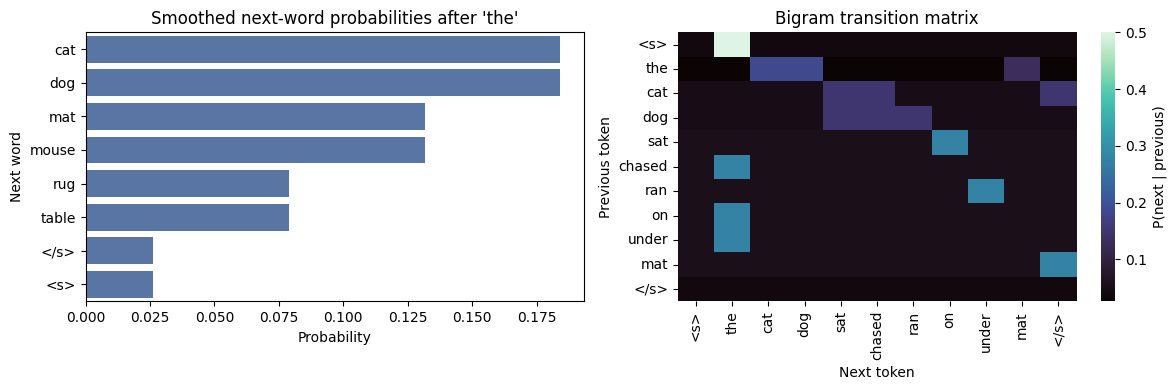

In [6]:
toy_lm_corpus = [
    'the cat sat on the mat',
    'the dog sat on the rug',
    'the cat chased the mouse',
    'the dog chased the cat',
    'the mouse ran under the mat',
    'the dog ran under the table',
]


def lm_tokens(text):
    return ['<s>'] + spacy_preprocess(text, remove_stop=False, keep_alpha=True, min_len=1) + ['</s>']


lm_tokenized = [lm_tokens(text) for text in toy_lm_corpus]
unigram_counts = Counter(token for sent in lm_tokenized for token in sent)
bigram_counts = Counter(
    (sent[i - 1], sent[i])
    for sent in lm_tokenized
    for i in range(1, len(sent))
)
vocab = sorted(unigram_counts)
alpha = 0.5


def bigram_probability(previous, word, alpha=0.5):
    numerator = bigram_counts[(previous, word)] + alpha
    denominator = unigram_counts[previous] + alpha * len(vocab)
    return numerator / denominator


next_word_table = pd.DataFrame({
    'next_word': vocab,
    "P(next | 'the')": [bigram_probability('the', word, alpha=alpha) for word in vocab],
}).sort_values("P(next | 'the')", ascending=False)

transition_words = ['<s>', 'the', 'cat', 'dog', 'sat', 'chased', 'ran', 'on', 'under', 'mat', '</s>']
transition_matrix = pd.DataFrame(
    [[bigram_probability(prev, word, alpha=alpha) for word in transition_words] for prev in transition_words],
    index=transition_words,
    columns=transition_words,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=next_word_table.head(8), x="P(next | 'the')", y='next_word', color='#4C72B0', ax=axes[0])
axes[0].set_title("Smoothed next-word probabilities after 'the'")
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Next word')

sns.heatmap(transition_matrix, cmap='mako', ax=axes[1], cbar_kws={'label': 'P(next | previous)'})
axes[1].set_title('Bigram transition matrix')
axes[1].set_xlabel('Next token')
axes[1].set_ylabel('Previous token')

plt.tight_layout()
next_word_table.head(8)


### 2a. Entropy, cross-entropy, and perplexity

Entropy is expected surprise under a distribution:

$$
H(p) = -\sum_w p(w)\log p(w).
$$

For a language model, cross-entropy is the average negative log probability assigned to observed tokens. Perplexity is the exponentiated cross-entropy:

$$
\mathrm{PP} = \exp\left(-\frac{1}{T}\sum_{t=1}^T \log P(w_t \mid w_{t-1})\right).
$$

Lower perplexity means the sentence is less surprising under the model. It does not mean the sentence is substantively more useful.


In [7]:
def sentence_log_probability(sentence, alpha=0.5):
    tokens = lm_tokens(sentence)
    log_probs = []
    for i in range(1, len(tokens)):
        prob = bigram_probability(tokens[i - 1], tokens[i], alpha=alpha)
        log_probs.append(np.log(prob))
    return sum(log_probs), len(log_probs)


def sentence_perplexity(sentence, alpha=0.5):
    log_prob, n_tokens = sentence_log_probability(sentence, alpha=alpha)
    return np.exp(-log_prob / n_tokens)

unigram_total = sum(unigram_counts.values())
unigram_probs = np.array([unigram_counts[word] / unigram_total for word in vocab])
entropy_bits = -(unigram_probs * np.log2(unigram_probs)).sum()

scored_sentences = pd.DataFrame({
    'sentence': [
        'the cat sat on the mat',
        'the dog chased the cat',
        'the mat chased the dog',
        'mouse table cat the',
    ]
})
scored_sentences['bigram_log_probability'] = scored_sentences['sentence'].apply(
    lambda sentence: sentence_log_probability(sentence, alpha=alpha)[0]
)
scored_sentences['bigram_perplexity'] = scored_sentences['sentence'].apply(
    lambda sentence: sentence_perplexity(sentence, alpha=alpha)
)

print(f'Unigram entropy of the toy corpus: {entropy_bits:.2f} bits')
scored_sentences.sort_values('bigram_perplexity')


Unigram entropy of the toy corpus: 3.40 bits


,sentence,bigram_log_probability,bigram_perplexity
0,the cat sat on the mat,-10.152893,4.264877
1,the dog chased the cat,-9.151673,4.596425
2,the mat chased the dog,-11.580009,6.889521
3,mouse table cat the,-15.554375,22.440673


## 3. LLM annotation with Ollama as codebook design

A local LLM call is one implementation of a measurement decision. The broader workflow is the same as with human coding or supervised classification: define the construct, record the prompt, apply it consistently, validate it against known labels, and inspect disagreements.

The code below uses Ollama's local HTTP API. It is off by default so the notebook still runs on machines without Ollama. For a live demo, start Ollama and set `RUN_OLLAMA_ANNOTATION = True`.

In [8]:
RUN_OLLAMA_ANNOTATION = False
REFRESH_OLLAMA_CACHE = False

OLLAMA_BASE_URL = 'http://localhost:11434'
OLLAMA_MODEL = 'llama3:latest'
OLLAMA_SAMPLE_SIZE = 40
OLLAMA_TIMEOUT_SECONDS = 90

CACHE_DIR = DATA_DIR.parent / 'llm_cache'
safe_model_name = re.sub(r'[^A-Za-z0-9_.-]+', '_', OLLAMA_MODEL)
OLLAMA_CACHE_PATH = CACHE_DIR / f'tweet_eval_sentiment_{safe_model_name}_n{OLLAMA_SAMPLE_SIZE}.csv'

annotation_versions = ['v1_zero_shot', 'v2_few_shot']

per_class = max(1, OLLAMA_SAMPLE_SIZE // 2)
ollama_eval_pieces = []
for polarity, group in sample.groupby('polarity'):
    n_to_draw = min(len(group), per_class)
    ollama_eval_pieces.append(group.sample(n_to_draw, random_state=42))

ollama_eval_sample = (
    pd.concat(ollama_eval_pieces, ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

prompt_log = pd.DataFrame([
    {
        'version': 'v1_zero_shot',
        'model': OLLAMA_MODEL,
        'task': 'Classify a social media post as positive or negative.',
        'allowed_labels': 'positive, negative',
        'notes': 'No examples. Deterministic local Ollama call.'
    },
    {
        'version': 'v2_few_shot',
        'model': OLLAMA_MODEL,
        'task': 'Classify sentiment after considering negation, sarcasm, and evaluative words.',
        'allowed_labels': 'positive, negative',
        'notes': 'Adds examples in the prompt, then uses the same validation code.'
    }
])

print('Ollama model:', OLLAMA_MODEL)
print('Annotation sample size:', len(ollama_eval_sample))
print('Cache path:', OLLAMA_CACHE_PATH)
display(prompt_log)

Ollama model: llama3:latest
Annotation sample size: 40
Cache path: ../llm_cache/tweet_eval_sentiment_llama3_latest_n40.csv


,version,model,task,allowed_labels,notes
0,v1_zero_shot,llama3:latest,Classify a social media post as positive or negative.,"positive, negative",No examples. Deterministic local Ollama call.
1,v2_few_shot,llama3:latest,"Classify sentiment after considering negation, sarcasm, and evaluative words.","positive, negative","Adds examples in the prompt, then uses the same validation code."


In [9]:
def ollama_models(base_url=OLLAMA_BASE_URL, timeout=5):
    # Return locally available Ollama model names.
    request = urllib.request.Request(f'{base_url.rstrip("/")}/api/tags')
    with urllib.request.urlopen(request, timeout=timeout) as response:
        payload = json.loads(response.read().decode('utf-8'))
    return [model['name'] for model in payload.get('models', [])]


def sentiment_prompt(text, version='v1_zero_shot'):
    if version == 'v1_zero_shot':
        return (
            'Classify the sentiment of the following social media post.\n'
            'Allowed labels: positive, negative.\n'
            'Output exactly one label and no explanation.\n\n'
            f'Post: {text}'
        )
    if version == 'v2_few_shot':
        return (
            'You are annotating sentiment in short social media posts.\n'
            'Use exactly one of these labels: positive, negative.\n'
            'Consider negation, intensifiers, sarcasm cues, and evaluative adjectives.\n\n'
            'Examples:\n'
            'Post: I love this, best news all week.\nLabel: positive\n'
            'Post: This is not good and I hate the update.\nLabel: negative\n'
            'Post: Great, another broken feature.\nLabel: negative\n\n'
            'Now classify this post. Output exactly one label and no explanation.\n'
            f'Post: {text}\nLabel:'
        )
    raise ValueError(f'Unknown prompt version: {version}')


def normalize_sentiment_label(raw_label):
    text = str(raw_label).strip().lower()
    text = re.sub(r'[^a-z\s-]', ' ', text)
    words = re.findall(r'positive|negative', text)
    if len(words) == 1:
        return words[0]
    if words:
        return words[0]
    return 'invalid'


def ollama_chat(prompt, model=OLLAMA_MODEL, base_url=OLLAMA_BASE_URL, timeout=OLLAMA_TIMEOUT_SECONDS):
    payload = {
        'model': model,
        'stream': False,
        'messages': [
            {
                'role': 'system',
                'content': 'You are a careful text annotation assistant. Follow the label set exactly.'
            },
            {'role': 'user', 'content': prompt}
        ],
        'options': {
            'temperature': 0,
            'seed': 2026,
            'num_predict': 8
        }
    }
    request = urllib.request.Request(
        f'{base_url.rstrip("/")}/api/chat',
        data=json.dumps(payload).encode('utf-8'),
        headers={'Content-Type': 'application/json'},
        method='POST'
    )
    with urllib.request.urlopen(request, timeout=timeout) as response:
        result = json.loads(response.read().decode('utf-8'))
    return result.get('message', {}).get('content', '').strip()


def annotate_with_ollama(frame, versions=annotation_versions):
    rows = []
    for row_number, row in frame.reset_index(drop=True).iterrows():
        record = {
            'row_number': row_number,
            'text': row['text'],
            'polarity': row['polarity'],
        }
        for version in versions:
            prompt = sentiment_prompt(row['text'], version=version)
            raw_label = ollama_chat(prompt)
            record[f'llm_{version}_raw'] = raw_label
            record[f'llm_{version}_label'] = normalize_sentiment_label(raw_label)
            time.sleep(0.05)
        rows.append(record)
    return pd.DataFrame(rows)


if OLLAMA_CACHE_PATH.exists() and not REFRESH_OLLAMA_CACHE:
    ollama_annotations = pd.read_csv(OLLAMA_CACHE_PATH)
    print(f'Loaded cached Ollama annotations from {OLLAMA_CACHE_PATH}')
elif RUN_OLLAMA_ANNOTATION:
    try:
        available_models = ollama_models()
        if OLLAMA_MODEL not in available_models:
            raise ValueError(
                f'{OLLAMA_MODEL!r} is not available. Available Ollama models: {available_models}'
            )
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        ollama_annotations = annotate_with_ollama(ollama_eval_sample)
        ollama_annotations.to_csv(OLLAMA_CACHE_PATH, index=False)
        print(f'Saved Ollama annotations to {OLLAMA_CACHE_PATH}')
    except (urllib.error.URLError, TimeoutError, ValueError) as exc:
        ollama_annotations = pd.DataFrame()
        print('Ollama annotation skipped:', exc)
        print('Start Ollama, check `ollama list`, then set RUN_OLLAMA_ANNOTATION=True.')
else:
    ollama_annotations = pd.DataFrame()
    print('Ollama annotation not run. Set RUN_OLLAMA_ANNOTATION=True to query the local model.')

if not ollama_annotations.empty:
    display(ollama_annotations.head())

Loaded cached Ollama annotations from ../llm_cache/tweet_eval_sentiment_llama3_latest_n40.csv


,row_number,text,polarity,llm_v1_zero_shot_raw,llm_v1_zero_shot_label,llm_v2_few_shot_raw,llm_v2_few_shot_label
0,0,"""Stupid update mistake of the night: The Mariners beat the A's 11-8, not the White Sox. I'm the worst. You may now proceed with your Sun...",negative,negative,negative,negative,negative
1,1,@user not one word deploring attacks on Charlie Hebdo nor barbaric nature of islam in the 21st C as long as it's sharia compliant,negative,negative,negative,negative,negative
2,2,@user Damn\u002c I just got Cougar Town cupcakes and was going to bring them tomorrow to share. I *shouldn\u2019t* eat all 12 alone...,negative,negative,negative,negative,negative
3,3,So my sister and I are going to Ed Sheeran on Saturday...,positive,positive,positive,positive,positive
4,4,Recent EU behaviour 1: Convulsive and prolonged grief for tyrant and mass murderer Fidel Castro.,negative,negative,negative,negative,negative


In [10]:
def metrics(y_true, y_pred):
    return pd.Series({
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label='positive', zero_division=0),
        'recall': recall_score(y_true, y_pred, pos_label='positive', zero_division=0),
        'f1': f1_score(y_true, y_pred, pos_label='positive', zero_division=0)
    })


if not ollama_annotations.empty:
    rows = []
    for version in annotation_versions:
        label_col = f'llm_{version}_label'
        valid = ollama_annotations[label_col].isin(['positive', 'negative'])
        row = metrics(
            ollama_annotations.loc[valid, 'polarity'],
            ollama_annotations.loc[valid, label_col]
        )
        row['version'] = version
        row['n_valid'] = valid.sum()
        row['n_invalid'] = (~valid).sum()
        rows.append(row)
    ollama_metric_table = pd.DataFrame(rows).set_index('version')
    display(ollama_metric_table[['n_valid', 'n_invalid', 'accuracy', 'precision', 'recall', 'f1']].round(3))
else:
    print('No Ollama annotations available yet, so there are no validation metrics to display.')

,n_valid,n_invalid,accuracy,precision,recall,f1
version,,,,,,
v1_zero_shot,40,0,0.950,1.0,0.90,0.947
v2_few_shot,40,0,0.925,1.0,0.85,0.919


## 3a. Annotation confusion matrices

LLM annotation needs the same diagnostic discipline as supervised classification: which mistakes are being made, and are they substantively acceptable? A polished prompt is not validation evidence by itself.

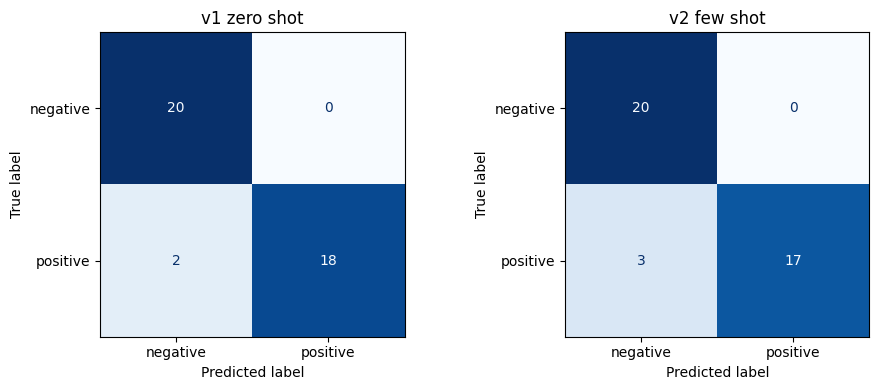

In [11]:
if not ollama_annotations.empty:
    fig, axes = plt.subplots(1, len(annotation_versions), figsize=(4.8 * len(annotation_versions), 4))
    if len(annotation_versions) == 1:
        axes = [axes]

    for ax, version in zip(axes, annotation_versions):
        label_col = f'llm_{version}_label'
        valid = ollama_annotations[label_col].isin(['positive', 'negative'])
        ConfusionMatrixDisplay.from_predictions(
            ollama_annotations.loc[valid, 'polarity'],
            ollama_annotations.loc[valid, label_col],
            ax=ax,
            cmap='Blues',
            colorbar=False
        )
        ax.set_title(version.replace('_', ' '))

    plt.tight_layout()
else:
    print('No confusion matrix: run or load Ollama annotations first.')

In [12]:
if not ollama_annotations.empty:
    preferred_version = 'v2_few_shot'
    label_col = f'llm_{preferred_version}_label'
    raw_col = f'llm_{preferred_version}_raw'
    valid = ollama_annotations[label_col].isin(['positive', 'negative'])
    disagreements = ollama_annotations[
        valid & (ollama_annotations['polarity'] != ollama_annotations[label_col])
    ].copy()

    if disagreements.empty:
        print(f'No disagreements for {preferred_version} on this annotation sample.')
    else:
        display(
            disagreements[['text', 'polarity', label_col, raw_col]]
            .rename(columns={label_col: 'llm_label', raw_col: 'raw_response'})
            .head(10)
        )
else:
    print('No disagreement table: run or load Ollama annotations first.')

,text,polarity,llm_label,raw_response
6,"@user @user Funny how you call it """"Thursday"""" and don't believe Thor was real.""",positive,negative,negative
10,Lumber Jack out tomorrow as we take down the Colts!,positive,negative,negative
38,Yep... they are staying put... Amazing work Mike Pence,positive,negative,negative


### Practical Ollama notes

For the local setup you showed, `llama3:latest` is the best default for this section. `embeddinggemma:latest` is an embedding model, so it belongs in representation examples rather than chat-style annotation. `gpt-oss:120b-cloud` may be useful if your Ollama setup routes to a cloud model, but it is not necessary for the classroom workflow.

The point of the section is not that Ollama labels are automatically correct. The point is that local LLM annotation can be inserted into the same validation pipeline: fixed prompt, fixed label set, cached outputs, held-out labels, metrics, confusion matrix, and error review.

In [13]:
prompt_preview = pd.DataFrame([
    {
        'version': version,
        'example_prompt': sentiment_prompt(ollama_eval_sample.loc[0, 'text'], version=version)
    }
    for version in annotation_versions
])

display(prompt_preview)

,version,example_prompt
0,v1_zero_shot,"Classify the sentiment of the following social media post.\nAllowed labels: positive, negative.\nOutput exactly one label and no explana..."
1,v2_few_shot,"You are annotating sentiment in short social media posts.\nUse exactly one of these labels: positive, negative.\nConsider negation, inte..."


## 4. Static Word2Vec embeddings from local context windows

The slides describe Word2Vec as a static embedding model: one vector per word, learned by predicting surrounding context. Here we train a small skip-gram Word2Vec model locally with `gensim`, using the bundled TweetEval corpus.

This is intentionally a classroom-sized model rather than a large pretrained embedding. The downstream workflow is the same as with pretrained Word2Vec or spaCy medium/large vectors: inspect nearest neighbors, average word vectors into document vectors, train classifiers, and construct semantic axes.


### Methodology formulas: embeddings, annotation, and semantic axes

An annotation model can be written as a function from text and a codebook or prompt $p$ to a label:

$$\hat{y}_i = f_p(x_i).$$

Static embeddings map each word type to one vector:

$$w \mapsto v_w \in \mathbb{R}^d.$$

Word2Vec learns these vectors by predicting context words. A compact skip-gram objective with negative sampling is:

$$
\log \sigma(v_w^\top v_c) + \sum_{n \sim P_n} \log \sigma(-v_w^\top v_n).
$$

The local `gensim` model optimizes this predictive objective on the bundled corpus: words that occur in similar context windows get nearby vectors. Document vectors are simple averages of their word vectors:

$$z_i = \frac{1}{|D_i|}\sum_{w\in D_i} v_w.$$

Documents are compared by cosine similarity:

$$\mathrm{sim}(i,j)=\frac{z_i^\top z_j}{\lVert z_i\rVert_2\lVert z_j\rVert_2}.$$

A semantic axis contrasts two anchor sets, for example positive versus negative seed words:

$$a = \frac{\bar{v}_{+} - \bar{v}_{-}}{\lVert \bar{v}_{+} - \bar{v}_{-}\rVert_2}, \qquad s_i = z_i^\top a.$$

Classification on embeddings then estimates

$$P(y_i=1 \mid z_i)=\sigma(\gamma_0 + z_i^\top\gamma).$$

This is why prompt design, label validation, and embedding diagnostics belong together: all three define the measurement function that turns text into data.


In [14]:
def embedding_tokens(text):
    return spacy_preprocess(text, remove_stop=True, keep_alpha=True, min_len=2)


def average_word2vec_embeddings(texts, model):
    rows = []
    for text in texts:
        tokens = embedding_tokens(text)
        vectors = [model.wv[token] for token in tokens if token in model.wv]
        if vectors:
            rows.append(np.mean(vectors, axis=0))
        else:
            rows.append(np.zeros(model.vector_size))
    return np.vstack(rows)


seed_calibration_texts = [
    'great love happy thanks awesome good excellent amazing fun proud smile win',
    'bad hate sad angry worst terrible awful poor wrong fail fear pain',
]

word2vec_training_texts = tweets['text'].dropna().tolist() + seed_calibration_texts
word2vec_sentences = [embedding_tokens(text) for text in word2vec_training_texts]

word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=50,
    window=5,
    min_count=2,
    sg=1,
    negative=10,
    epochs=30,
    workers=1,
    seed=42,
)

embeddings = average_word2vec_embeddings(sample['text'], word2vec_model)

print(f'document embeddings: {embeddings.shape}')
print(f'Word2Vec vocabulary: {len(word2vec_model.wv)} words')


document embeddings: (500, 50)
Word2Vec vocabulary: 3165 words


### 4a. Nearest neighbors in the local word-embedding space

Static embeddings are useful because words can be compared geometrically. The nearest-neighbor lists below are not meant to be state-of-the-art; they make the distributional logic visible on a small local corpus.


In [15]:
def nearest_words(word, n=8):
    if word not in word2vec_model.wv:
        return pd.DataFrame({'message': [f'{word!r} is not in the local Word2Vec vocabulary']})
    return pd.DataFrame(
        word2vec_model.wv.most_similar(word, topn=n),
        columns=['word', 'similarity'],
    )


for query_word in ['game', 'happy', 'win', 'thanks']:
    print(f'Nearest words to {query_word!r}:')
    display(nearest_words(query_word, n=6))


Nearest words to 'game':


,word,similarity
0,redskins,0.821946
1,hyped,0.807733
2,lakers,0.803537
3,thrones,0.799633
4,vs,0.799344
5,td,0.785013


Nearest words to 'happy':


,word,similarity
0,tipp,0.804638
1,wilt,0.794118
2,chamberlain,0.786347
3,birthday,0.780135
4,late,0.778024
5,gorgeous,0.763756


Nearest words to 'win':


,word,similarity
0,clutch,0.781780
1,jazz,0.752795
2,hawks,0.751849
3,electoral,0.734784
4,encouraging,0.733855
5,mitchell,0.728429


Nearest words to 'thanks':


,word,similarity
0,daily,0.867148
1,latest,0.856018
2,travel,0.854556
3,mail,0.791176
4,ty,0.755143
5,deeplearning,0.747358


## 4b. Embedding map

The classifier and similarity calculations use the full 50-dimensional averaged Word2Vec vectors. PCA is used only to display those document vectors in two dimensions.


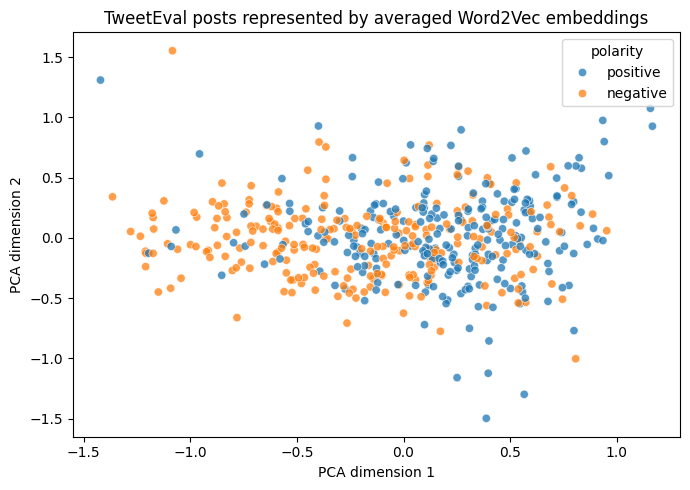

In [16]:
embedding_map = PCA(n_components=2, random_state=42).fit_transform(embeddings)
sample['embedding_x'] = embedding_map[:, 0]
sample['embedding_y'] = embedding_map[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=sample, x='embedding_x', y='embedding_y', hue='polarity', alpha=0.75)
plt.title('TweetEval posts represented by averaged Word2Vec embeddings')
plt.xlabel('PCA dimension 1')
plt.ylabel('PCA dimension 2')
plt.tight_layout()


In [17]:
def nearest_posts(row_index, n=6):
    sims = cosine_similarity(embeddings[row_index:row_index + 1], embeddings).ravel()
    order = sims.argsort()[::-1][1:n + 1]
    return sample.loc[order, ['text', 'polarity']].assign(similarity=sims[order])

print(sample.loc[0, 'text'])
nearest_posts(0, n=6)

@user @user wow,wow,so beautiful life!!enjoy it ok!!both be the best forever!!


,text,polarity,similarity
220,@user @user Etta James\u002c fine. She may have the best voice but she still killed it. Slaughtered it\u002c in fact.,positive,0.917459
62,"We the best, no Khaled,We the best like Ali, Muhammad",positive,0.889838
321,"Other than Lorelai and Rory, #GilmoreGirlsTop4 characters are: 4.Sookie 3.Kirk 2.Jess",positive,0.860278
68,"@user Ok, you may have to create an email that is shorter. The PS4 cannot handle that many characters for some reason. ^SO""",negative,0.852395
79,I probs say this every Tuesday but Paper Towns is the best film I've actually seen and it just makes me love life,positive,0.850356
382,Danica Patrick let her temper get the best of her Sunday and knocked herself out of NASCAR race,negative,0.846935


## 5. Classification with averaged word embeddings

Averaged static word embeddings can be used as features in a supervised classifier. Compare this to sparse TF-IDF classifiers: the representation is dense and semantic, but it may lose useful word-level details.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    sample['polarity'],
    test_size=0.25,
    random_state=42,
    stratify=sample['polarity']
)

embedding_model = LogisticRegression(max_iter=1000)
embedding_model.fit(X_train, y_train)
embedding_pred = embedding_model.predict(X_test)

metrics(y_test, embedding_pred).round(3)

accuracy     0.704
precision    0.712
recall       0.677
f1           0.694
dtype: float64

## 5a. Classifier error map

Projecting predictions back into the embedding space helps identify regions where the classifier is uncertain or systematically wrong.

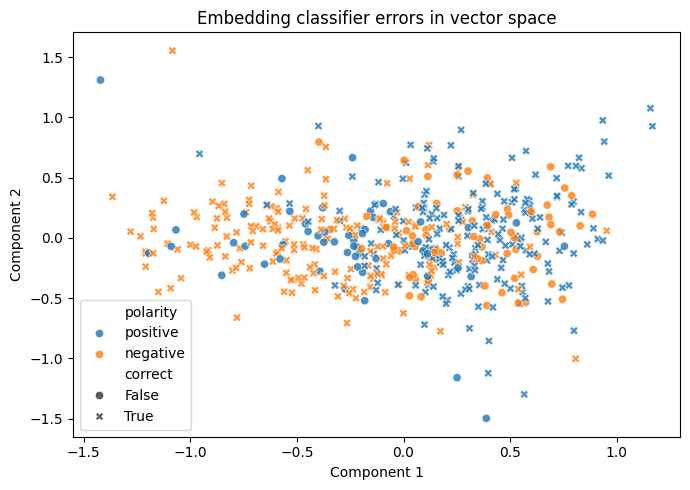

In [19]:
embedding_eval = sample.copy()
embedding_eval['embedding_prediction'] = embedding_model.predict(embeddings)
embedding_eval['correct'] = embedding_eval['embedding_prediction'].eq(embedding_eval['polarity'])

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=embedding_eval,
    x='embedding_x',
    y='embedding_y',
    hue='polarity',
    style='correct',
    alpha=0.8
)
plt.title('Embedding classifier errors in vector space')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()

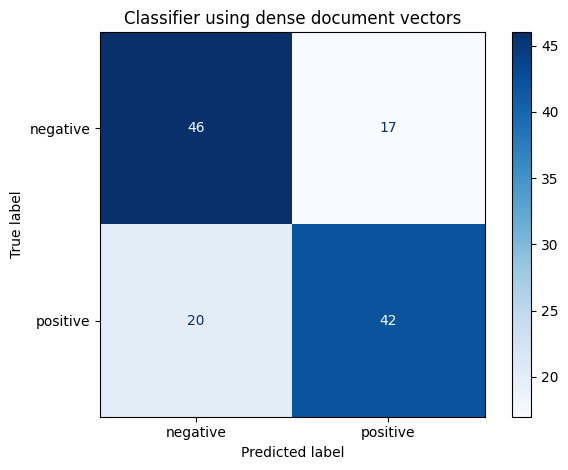

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, embedding_pred, cmap='Blues')
plt.title('Classifier using dense document vectors')
plt.tight_layout()

## 6. Semantic axis

A semantic axis turns seed words into a direction in vector space. The measurement question is whether the chosen seeds validly represent the construct.

In [21]:
def embed_texts(texts):
    return average_word2vec_embeddings(texts, word2vec_model)


def seed_center(seed_words):
    vectors = [word2vec_model.wv[word] for word in seed_words if word in word2vec_model.wv]
    if not vectors:
        raise ValueError('None of the seed words are in the local Word2Vec vocabulary.')
    return np.mean(vectors, axis=0)


positive_seed_words = ['great', 'love', 'happy', 'thanks', 'awesome']
negative_seed_words = ['bad', 'hate', 'sad', 'angry', 'worst']

pos_center = seed_center(positive_seed_words)
neg_center = seed_center(negative_seed_words)
axis = pos_center - neg_center
axis = axis / np.linalg.norm(axis)

sample['semantic_axis_score'] = embeddings @ axis
sample.groupby('polarity')['semantic_axis_score'].describe()


,count,mean,std,min,25%,50%,75%,max
polarity,,,,,,,,
negative,250.0,0.006065,0.260548,-1.055996,-0.145025,0.021438,0.171275,0.716992
positive,250.0,0.223591,0.283760,-0.657872,0.045683,0.199749,0.412462,1.131556


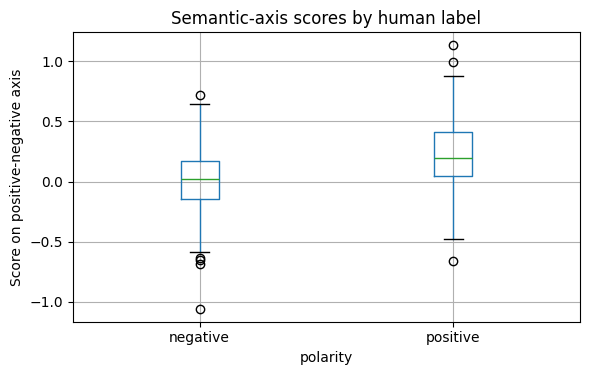

In [22]:
sample.boxplot(column='semantic_axis_score', by='polarity', figsize=(6, 4))
plt.title('Semantic-axis scores by human label')
plt.suptitle('')
plt.ylabel('Score on positive-negative axis')
plt.tight_layout()

## 6a. Semantic-axis distribution

The axis is useful only if it separates cases in an interpretable and stable way. A distribution plot makes overlap visible.

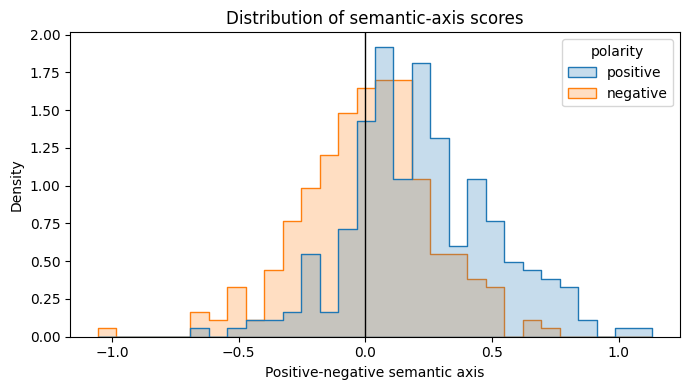

In [23]:
plt.figure(figsize=(7, 4))
sns.histplot(data=sample, x='semantic_axis_score', hue='polarity', bins=30, element='step', stat='density', common_norm=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Distribution of semantic-axis scores')
plt.xlabel('Positive-negative semantic axis')
plt.tight_layout()

### Additional demo: semantic-axis sensitivity

Semantic axes depend on anchor words. This demonstration compares several plausible positive-negative axes and checks whether the class separation is stable.

,axis_name,negative_mean,positive_mean,class_separation
0,original seeds,0.006,0.224,0.218
1,general sentiment,0.128,0.379,0.251
2,social reaction,0.104,0.219,0.115


,position,polarity,semantic_axis_score,text
167,lowest on original axis,negative,-1.055996,Bad Hombres on the Block #TrumpInauguralBands
245,lowest on original axis,negative,-0.686210,No more saying Trump associates with the alt-right. They're white supremacists and so is he. DONALD TRUMP IS A WHITE SUPREMACIST.
106,lowest on original axis,positive,-0.657872,"""\""""""""@_eryflores: March 16 Luke Bryan is gonna at the Houston Rodeo. I HAVE to go\u002c Its a MUST!\"""""""""""
488,lowest on original axis,negative,-0.651966,What is chilling? I get more stick from Muslims than I ever do from non-Muslims - am sorry it is the truth world - as much as it may pain
185,lowest on original axis,negative,-0.633047,@user Trump's not qualified to see promises thru. That's bad. Hillary IS qualified to get hers thru. That's worse. #TPP #Fracking
376,highest on original axis,positive,1.131556,@user happy Birthday Tipp
95,highest on original axis,positive,0.995719,Ice cold cider coupled with the sounds of Iron Maiden. Great Monday night...
126,highest on original axis,positive,0.879172,Todays #ullukapatha is Rahul Gandhi . You may ask WHY ? Nothing . Just that he is a filler on days we have no Ullukapathas . Happy Diwali
63,highest on original axis,positive,0.844620,Happy Goodwill Wednesday! I almost forgot what day it was. Stupid Labor Day weekend has me all jacked up....
442,highest on original axis,positive,0.822164,"""Happy Labor Day this weekend...or as Scott Walker calls it, """"Monday!"""""""


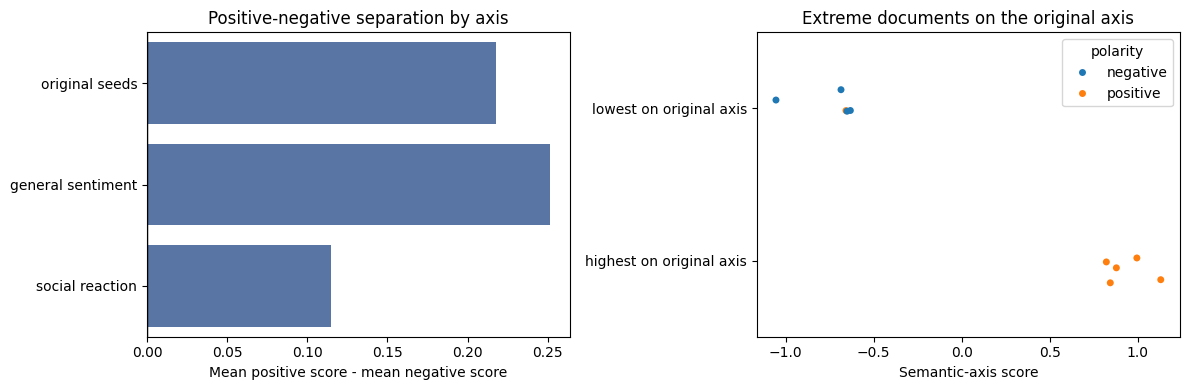

In [24]:
axis_specs = [
    {
        'axis_name': 'original seeds',
        'positive': ['great', 'love', 'happy', 'thanks', 'awesome'],
        'negative': ['bad', 'hate', 'sad', 'angry', 'worst']
    },
    {
        'axis_name': 'general sentiment',
        'positive': ['good', 'best', 'amazing', 'excellent', 'fun'],
        'negative': ['terrible', 'awful', 'poor', 'mess', 'wrong']
    },
    {
        'axis_name': 'social reaction',
        'positive': ['congrats', 'enjoy', 'smile', 'win', 'thank'],
        'negative': ['cry', 'fear', 'pain', 'fail', 'angry']
    }
]

axis_rows = []
for spec in axis_specs:
    pos = seed_center(spec['positive'])
    neg = seed_center(spec['negative'])
    candidate_axis = pos - neg
    norm = np.linalg.norm(candidate_axis)
    if norm == 0:
        continue
    candidate_axis = candidate_axis / norm
    scores = embeddings @ candidate_axis
    means = sample.assign(axis_score=scores).groupby('polarity')['axis_score'].mean()
    axis_rows.append({
        'axis_name': spec['axis_name'],
        'negative_mean': means.get('negative', np.nan),
        'positive_mean': means.get('positive', np.nan),
        'class_separation': means.get('positive', np.nan) - means.get('negative', np.nan)
    })

axis_sensitivity = pd.DataFrame(axis_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=axis_sensitivity, x='class_separation', y='axis_name', color='#4C72B0', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Positive-negative separation by axis')
axes[0].set_xlabel('Mean positive score - mean negative score')
axes[0].set_ylabel('')

extremes = pd.concat([
    sample.nsmallest(5, 'semantic_axis_score').assign(position='lowest on original axis'),
    sample.nlargest(5, 'semantic_axis_score').assign(position='highest on original axis')
])
sns.stripplot(data=extremes, x='semantic_axis_score', y='position', hue='polarity', jitter=0.15, ax=axes[1])
axes[1].set_title('Extreme documents on the original axis')
axes[1].set_xlabel('Semantic-axis score')
axes[1].set_ylabel('')

plt.tight_layout()
display(axis_sensitivity.round(3))
extremes[['position', 'polarity', 'semantic_axis_score', 'text']]

## 6b. Advanced extension: semantic axis over time

The previous semantic-axis example used sentiment tweets. Here we use the same idea for political language.

We extract State of the Union sentences containing `freedom`, train a local Word2Vec model on all post-1900 SOTU sentences, and score each `freedom` sentence on a substantive axis:

$$
\text{rights/liberty/democracy} \quad \text{vs.} \quad \text{security/war/order}.
$$

Because `freedom` is usually close to rights/liberty language, we center the score around the average `freedom` sentence. Positive values therefore mean **more rights/liberty/democracy-oriented than typical freedom usage**, while negative values mean **more security/war/order-oriented than typical freedom usage**.

This is not a strict historical semantic-drift model with separately aligned embeddings. It is a more modest and interpretable question: when presidents use the word `freedom`, are the surrounding words relatively closer to a rights-democracy frame or a security-war-order frame, and does that association move over decades?

In [25]:
sotu = pd.read_csv(DATA_DIR / 'sotu.csv')
sotu['year_numeric'] = pd.to_numeric(sotu['year'], errors='coerce')

eligible_sotu = sotu[
    (sotu['year_numeric'] >= 1900)
    & sotu['party'].isin(['Democratic', 'Republican'])
    & sotu['text'].notna()
].copy()

# Use a lightweight spaCy sentencizer here; the full parser is unnecessary and much slower.
sentence_nlp = spacy.blank('en')
sentence_nlp.add_pipe('sentencizer')

sentence_rows = []
texts = eligible_sotu['text'].astype(str).tolist()
for (_, row), doc in zip(eligible_sotu.iterrows(), sentence_nlp.pipe(texts, batch_size=16)):
    for sent in doc.sents:
        sent_text = sent.text.strip()
        if len(sent_text.split()) < 5:
            continue
        sentence_rows.append({
            'year': int(row['year_numeric']),
            'decade': int(row['year_numeric'] // 10 * 10),
            'party': row['party'],
            'sentence': sent_text,
            'mentions_freedom': bool(re.search(r'\bfreedom\b', sent_text, flags=re.IGNORECASE)),
        })

sotu_sentences = pd.DataFrame(sentence_rows)
freedom = sotu_sentences[sotu_sentences['mentions_freedom']].copy().reset_index(drop=True)

coverage = (
    freedom
    .groupby(['decade', 'party'])
    .size()
    .reset_index(name='freedom_sentences')
)

print(f'All post-1900 Democratic/Republican SOTU sentences: {len(sotu_sentences):,}')
print(f"Sentences containing 'freedom': {len(freedom):,}")
display(coverage.pivot_table(index='decade', columns='party', values='freedom_sentences', fill_value=0).astype(int))
freedom[['year', 'party', 'sentence']].head()

All post-1900 Democratic/Republican SOTU sentences: 42,208
Sentences containing 'freedom': 626


party,Democratic,Republican
decade,,
1900,0,23
1910,13,9
1920,0,16
1930,6,4
1940,55,0
1950,43,71
1960,52,26
1970,6,31
1980,14,87


,year,party,sentence
0,1900,Republican,The additions which have been made to it proclaim larger freedom and more extended citizenship.
1,1900,Republican,In the meantime the municipal and departmental governments will continue to report to the Military Governor and be subject to his admini...
2,1900,Republican,"At the same time the Commission should bear in mind, and the people of the islands should be made plainly to understand, that there are ..."
3,1900,Republican,"Upon every division and branch of the government of the Philippines, therefore, must be imposed these inviolable rules:\n\nThat no perso..."
4,1900,Republican,"As high and sacred an obligation rests upon the Government of the United States to give protection for property and life, civil and reli..."


,axis_side,seed_words_used,missing_seed_words
0,rights/liberty/democracy,"rights, liberty, democracy, democratic, constitutional, justice",(none)
1,security/war/order,"security, war, order, defense, military, threat",(none)


,decade,party,n,mean_score,ci_low,ci_high
0,1900,Republican,23,0.128,0.050,0.206
1,1910,Democratic,13,-0.043,-0.114,0.028
2,1910,Republican,9,-0.091,-0.204,0.022
3,1920,Republican,16,0.048,-0.087,0.184
4,1930,Democratic,6,0.307,0.161,0.453
5,1930,Republican,4,0.061,-0.166,0.287
6,1940,Democratic,55,0.071,0.004,0.139
7,1950,Democratic,43,0.016,-0.060,0.091
8,1950,Republican,71,-0.059,-0.110,-0.008
9,1960,Democratic,52,-0.081,-0.131,-0.032


,position,year,party,rights_security_score,sentence
348,more security/war/order than average,1977,Republican,-0.821,"We must have superior naval and marine forces to maintain freedom of the seas, strong multipurpose tactical air forces, and mobile, mode..."
202,more security/war/order than average,1955,Republican,-0.728,The military threat is but one menace to our freedom and security.
227,more security/war/order than average,1959,Republican,-0.657,Each supplies part of a strategic deployment to protect the forward boundaries of freedom.
267,more security/war/order than average,1961,Republican,-0.632,"Our tactical air units overseas and our aircraft carriers are alert; Army units, guarding the frontiers of freedom in Europe and the Far..."
382,more security/war/order than average,1983,Republican,-0.556,We have developed a realistic military strategy to deter threats to peace and to protect freedom if deterrence fails.
526,more security/war/order than average,2002,Republican,-0.550,"My budget includes the largest increase in defense spending in two decades, because while the price of freedom and security is high, it ..."
144,more rights/liberty/democracy than average,1951,Democratic,0.770,We must uphold the freedom of speech and the freedom of conscience in our land.
75,more rights/liberty/democracy than average,1941,Democratic,0.731,The first is freedom of speech and expression-;everywhere in the world.
121,more rights/liberty/democracy than average,1948,Democratic,0.720,"Religious freedom, free speech, and freedom of thought are cherished realities in our land."
374,more rights/liberty/democracy than average,1982,Republican,0.658,We will also keep our freedom.


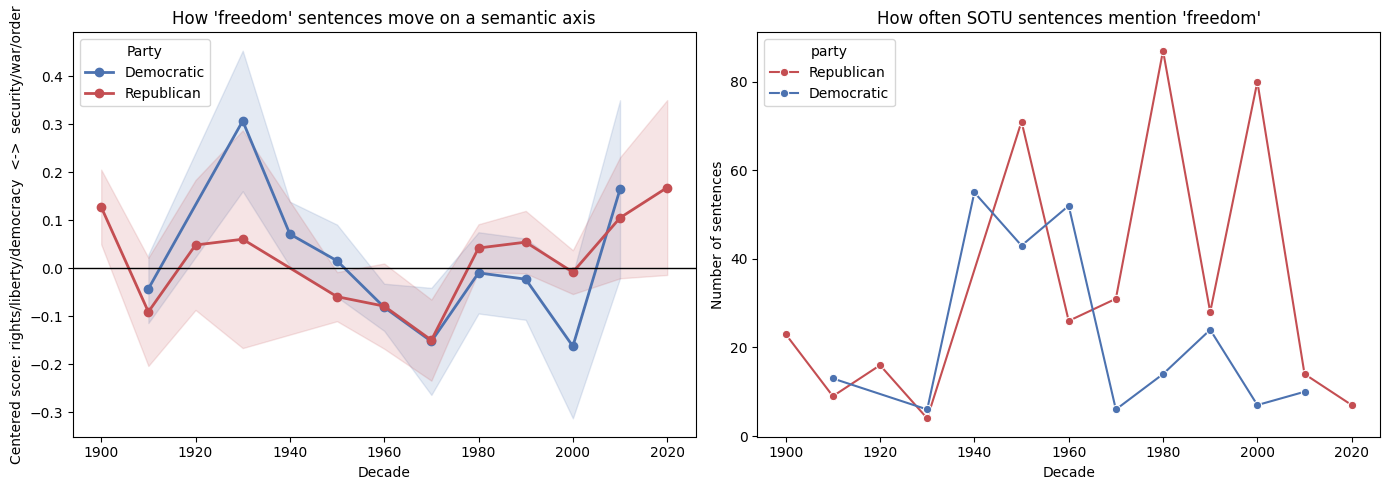

In [26]:
if len(freedom) >= 20:
    rights_anchor_words = ['rights', 'liberty', 'democracy', 'democratic', 'constitutional', 'justice']
    security_anchor_words = ['security', 'war', 'order', 'defense', 'military', 'threat']

    sotu_word2vec_sentences = [
        embedding_tokens(sentence)
        for sentence in sotu_sentences['sentence']
    ]
    sotu_word2vec_sentences = [tokens for tokens in sotu_word2vec_sentences if tokens]

    import contextlib
    import io

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        sotu_word2vec = Word2Vec(
            sentences=sotu_word2vec_sentences,
            vector_size=50,
            window=6,
            min_count=2,
            sg=1,
            negative=10,
            epochs=25,
            workers=1,
            seed=42,
        )

    def seed_center_for_model(seed_words, model):
        in_vocab = [word for word in seed_words if word in model.wv]
        missing = [word for word in seed_words if word not in model.wv]
        if not in_vocab:
            raise ValueError(f'None of these seed words are in the model vocabulary: {seed_words}')
        return np.mean([model.wv[word] for word in in_vocab], axis=0), in_vocab, missing

    rights_center, rights_in_vocab, rights_missing = seed_center_for_model(rights_anchor_words, sotu_word2vec)
    security_center, security_in_vocab, security_missing = seed_center_for_model(security_anchor_words, sotu_word2vec)

    rights_security_axis = rights_center - security_center
    rights_security_axis = rights_security_axis / np.linalg.norm(rights_security_axis)

    freedom_embeddings = average_word2vec_embeddings(freedom['sentence'], sotu_word2vec)
    freedom['rights_security_score_raw'] = freedom_embeddings @ rights_security_axis
    freedom['rights_security_score'] = (
        freedom['rights_security_score_raw'] - freedom['rights_security_score_raw'].mean()
    )
    freedom['axis_side'] = np.where(
        freedom['rights_security_score'] >= 0,
        'more rights/liberty/democracy than average',
        'more security/war/order than average'
    )

    seed_coverage = pd.DataFrame([
        {
            'axis_side': 'rights/liberty/democracy',
            'seed_words_used': ', '.join(rights_in_vocab),
            'missing_seed_words': ', '.join(rights_missing) if rights_missing else '(none)',
        },
        {
            'axis_side': 'security/war/order',
            'seed_words_used': ', '.join(security_in_vocab),
            'missing_seed_words': ', '.join(security_missing) if security_missing else '(none)',
        },
    ])
    display(seed_coverage)

    decade_summary = (
        freedom
        .groupby(['decade', 'party'])['rights_security_score']
        .agg(n='size', mean_score='mean', sd='std')
        .reset_index()
    )
    decade_summary['se'] = decade_summary['sd'] / np.sqrt(decade_summary['n'])
    decade_summary['ci95'] = (1.96 * decade_summary['se']).fillna(0)
    decade_summary['ci_low'] = decade_summary['mean_score'] - decade_summary['ci95']
    decade_summary['ci_high'] = decade_summary['mean_score'] + decade_summary['ci95']

    plot_summary = decade_summary[decade_summary['n'] >= 3].copy()
    palette = {'Democratic': '#4C72B0', 'Republican': '#C44E52'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for party, party_data in plot_summary.groupby('party'):
        party_data = party_data.sort_values('decade')
        color = palette.get(party, None)
        axes[0].plot(
            party_data['decade'].to_numpy(),
            party_data['mean_score'].to_numpy(),
            marker='o',
            linewidth=2,
            label=party,
            color=color,
        )
        axes[0].fill_between(
            party_data['decade'].to_numpy(),
            party_data['ci_low'].to_numpy(),
            party_data['ci_high'].to_numpy(),
            color=color,
            alpha=0.15,
        )

    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title("How 'freedom' sentences move on a semantic axis")
    axes[0].set_xlabel('Decade')
    axes[0].set_ylabel('Centered score: rights/liberty/democracy  <->  security/war/order')
    axes[0].legend(title='Party')

    freq = freedom.groupby(['decade', 'party']).size().reset_index(name='sentences')
    sns.lineplot(
        data=freq,
        x='decade',
        y='sentences',
        hue='party',
        marker='o',
        palette=palette,
        ax=axes[1],
    )
    axes[1].set_title("How often SOTU sentences mention 'freedom'")
    axes[1].set_xlabel('Decade')
    axes[1].set_ylabel('Number of sentences')

    plt.tight_layout()

    axis_examples = pd.concat([
        freedom.nsmallest(6, 'rights_security_score').assign(position='more security/war/order than average'),
        freedom.nlargest(6, 'rights_security_score').assign(position='more rights/liberty/democracy than average'),
    ])

    display(
        decade_summary
        .sort_values(['decade', 'party'])
        [['decade', 'party', 'n', 'mean_score', 'ci_low', 'ci_high']]
        .round(3)
    )
    display(
        axis_examples[
            ['position', 'year', 'party', 'rights_security_score', 'sentence']
        ].round({'rights_security_score': 3})
    )
else:
    print('Not enough freedom sentences for the semantic-axis-over-time visualization.')

## 7. Contextual embeddings: same word, different context

Static embeddings assign one vector to a word type. Contextual embeddings assign a vector to a word token in a sentence. The word `bank` should therefore have different representations in `river bank` and `central bank`.

The cells below are optional because they require the transformer stack and a model checkpoint. They are written as runnable code for students who installed the transformer environment. Leave `RUN_CONTEXTUAL_EMBEDDING_DEMO = False` for the base classroom environment.


In [27]:
RUN_CONTEXTUAL_EMBEDDING_DEMO = False
CONTEXTUAL_MODEL_NAME = 'bert-base-uncased'

context_sentences = pd.DataFrame([
    {'sense': 'river', 'text': 'The fisherman sat on the bank of the river.'},
    {'sense': 'finance', 'text': 'The central bank raised interest rates again.'},
    {'sense': 'account', 'text': 'She went to the bank to deposit her paycheck.'},
    {'sense': 'river', 'text': 'Flood water spilled over the bank after the storm.'},
])

context_sentences


,sense,text
0,river,The fisherman sat on the bank of the river.
1,finance,The central bank raised interest rates again.
2,account,She went to the bank to deposit her paycheck.
3,river,Flood water spilled over the bank after the storm.


In [28]:
if RUN_CONTEXTUAL_EMBEDDING_DEMO:
    if importlib.util.find_spec('transformers') is None or importlib.util.find_spec('torch') is None:
        raise ImportError('Install the optional transformer stack first: pip install -r materials/requirements-transformers.txt')

    import torch
    from transformers import AutoModel, AutoTokenizer, logging as hf_logging
    hf_logging.set_verbosity_error()

    tokenizer = AutoTokenizer.from_pretrained(CONTEXTUAL_MODEL_NAME)
    model = AutoModel.from_pretrained(CONTEXTUAL_MODEL_NAME)
    model.eval()

    def contextual_word_vector(text, target='bank'):
        encoded = tokenizer(text, return_tensors='pt')
        with torch.no_grad():
            output = model(**encoded)
        tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
        target_positions = [
            idx for idx, token in enumerate(tokens)
            if token.replace('##', '').lower() == target
        ]
        if not target_positions:
            raise ValueError(f'Could not find target token {target!r} in: {tokens}')
        vector = output.last_hidden_state[0, target_positions, :].mean(dim=0).numpy()
        return vector, tokens

    contextual_vectors = []
    tokenizations = []
    for _, row in context_sentences.iterrows():
        vector, tokens = contextual_word_vector(row['text'], target='bank')
        contextual_vectors.append(vector)
        tokenizations.append(tokens)

    contextual_vectors = np.vstack(contextual_vectors)
    context_sentences['tokens'] = tokenizations

    contextual_similarity = pd.DataFrame(
        cosine_similarity(contextual_vectors),
        index=context_sentences['sense'] + ': ' + context_sentences.index.astype(str),
        columns=context_sentences['sense'] + ': ' + context_sentences.index.astype(str),
    )

    display(context_sentences[['sense', 'text', 'tokens']])
    display(contextual_similarity.round(3))

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(contextual_similarity, annot=True, fmt='.2f', cmap='mako', vmin=0, vmax=1)
    plt.title("Contextual similarity of the token 'bank'")
    plt.tight_layout()
else:
    print('Skipped. Set RUN_CONTEXTUAL_EMBEDDING_DEMO = True after installing transformers and torch.')


Skipped. Set RUN_CONTEXTUAL_EMBEDDING_DEMO = True after installing transformers and torch.


### 7a. Using contextual embeddings

Once contextual vectors are computed, the downstream workflow is familiar: pool token vectors into document vectors, run nearest-neighbor search, cluster them, or train a classifier. The difference is that the representation is context-sensitive rather than one vector per word type.


In [29]:
if RUN_CONTEXTUAL_EMBEDDING_DEMO:
    def mean_pool(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    small_context_sample = sample.sample(80, random_state=42).reset_index(drop=True)
    encoded = tokenizer(
        small_context_sample['text'].tolist(),
        padding=True,
        truncation=True,
        max_length=96,
        return_tensors='pt',
    )
    with torch.no_grad():
        output = model(**encoded)
    contextual_doc_embeddings = mean_pool(output.last_hidden_state, encoded['attention_mask']).numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        contextual_doc_embeddings,
        small_context_sample['polarity'],
        test_size=0.25,
        random_state=42,
        stratify=small_context_sample['polarity'],
    )
    contextual_classifier = LogisticRegression(max_iter=1000)
    contextual_classifier.fit(X_train, y_train)
    contextual_pred = contextual_classifier.predict(X_test)

    print('Classifier using pooled contextual document embeddings:')
    display(metrics(y_test, contextual_pred).round(3))

    query_id = 0
    sims = cosine_similarity(contextual_doc_embeddings[query_id:query_id + 1], contextual_doc_embeddings).ravel()
    nearest = sims.argsort()[::-1][1:6]
    display(
        small_context_sample.loc[[query_id], ['text', 'polarity']].assign(role='query')
    )
    display(
        small_context_sample.loc[nearest, ['text', 'polarity']].assign(similarity=sims[nearest])
    )
else:
    print('Skipped. This cell demonstrates classifier and nearest-neighbor use after contextual embeddings are computed.')


Skipped. This cell demonstrates classifier and nearest-neighbor use after contextual embeddings are computed.


## 8. Student task

Choose one of these tasks:

1. Run the Ollama annotation section on 20-40 texts, compare zero-shot and few-shot prompts, and inspect the disagreements.
2. Change the seed words and check whether the sentiment semantic axis is stable.
3. Change the SOTU `freedom` axis anchors, for example rights/democracy versus security/order, and assess whether the decade pattern changes.
4. If you installed the transformer stack, run the contextual embedding demo and inspect whether the same word has different neighbors in different contexts.

Then answer:

1. What concept do the labels or seed words define?
2. Which examples score unexpectedly high or low?
3. What changes when the representation is static, contextual, or generated by an LLM prompt?
4. What validation evidence would you need before publication?

In [30]:
# Your turn: replace these seed words and recompute the axis.
student_positive_seeds = ['good', 'great', 'best']
student_negative_seeds = ['bad', 'worst', 'poor']

# Add your sensitivity check here.